In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error



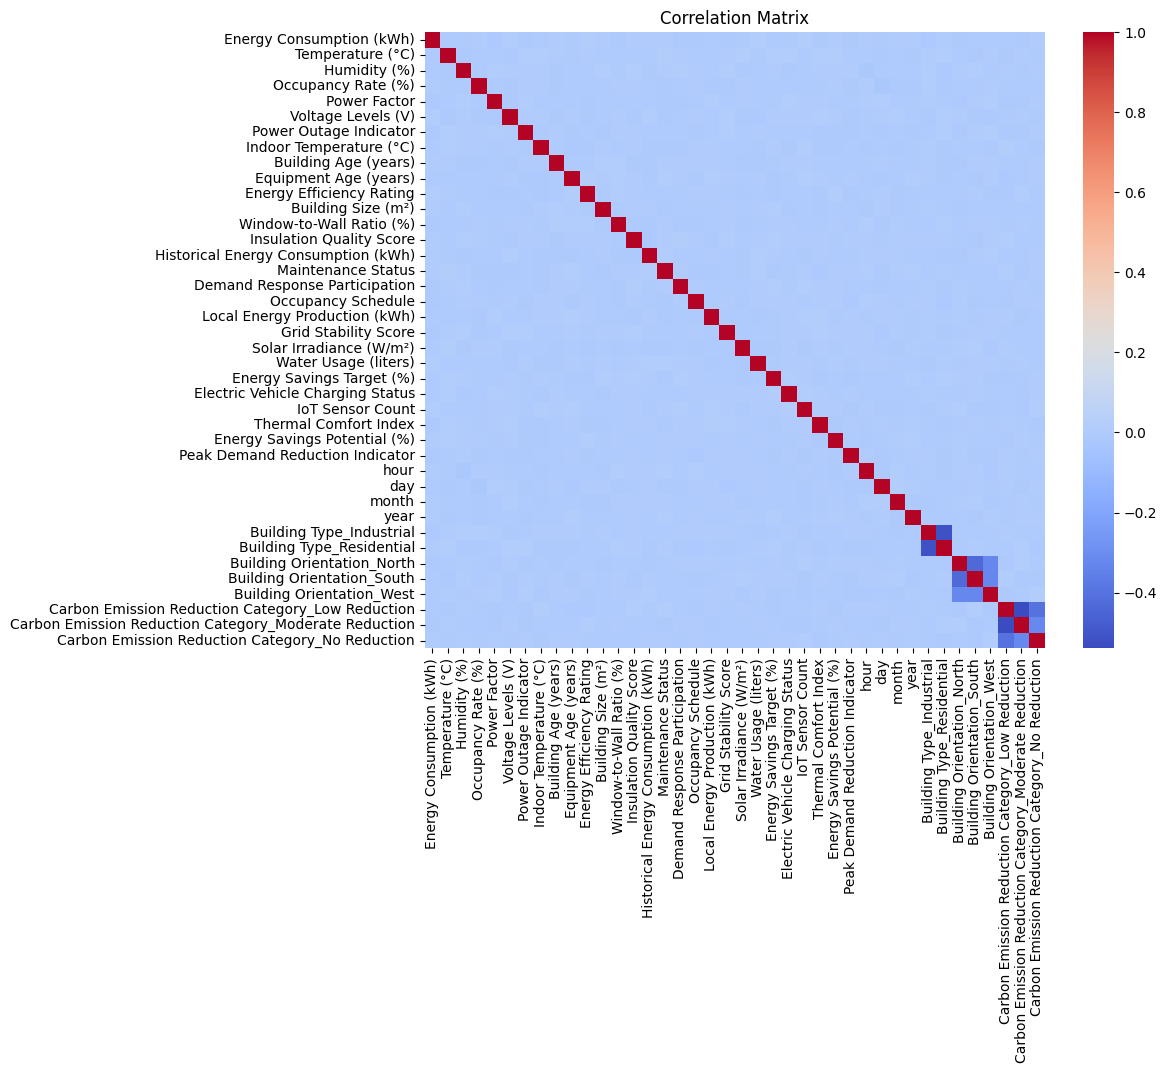

,Energy Consumption (kWh),Temperature (°C),Humidity (%),Occupancy Rate (%),Power Factor,Voltage Levels (V),Power Outage Indicator,Indoor Temperature (°C),Building Age (years),Equipment Age (years),...,month,year,Building Type_Industrial,Building Type_Residential,Building Orientation_North,Building Orientation_South,Building Orientation_West,Carbon Emission Reduction Category_Low Reduction,Carbon Emission Reduction Category_Moderate Reduction,Carbon Emission Reduction Category_No Reduction
Energy Consumption (kWh),1.000000,-0.000264,-0.000696,0.004371,-0.011922,0.010048,-0.009009,-0.003457,0.002709,0.001834,...,0.002107,0.003804,-0.010525,0.003094,-0.008475,-0.001538,0.001719,0.000309,-0.009207,0.007893
Temperature (°C),-0.000264,1.000000,-0.004707,0.000887,-0.002857,-0.006088,0.008543,0.011472,0.002248,0.001795,...,-0.001461,-0.008442,0.002352,0.011885,0.001570,-0.009841,0.004392,-0.008335,0.005567,-0.001105
Humidity (%),-0.000696,-0.004707,1.000000,-0.003114,0.010393,0.004539,0.003930,0.003477,-0.008333,0.000809,...,0.001826,-0.000921,0.008149,-0.010267,0.001912,0.009558,-0.002853,0.003918,-0.003607,0.003764
Occupancy Rate (%),0.004371,0.000887,-0.003114,1.000000,-0.000519,-0.006068,0.005374,0.002610,-0.004984,0.000877,...,-0.006389,-0.013045,0.009460,-0.005866,-0.002652,0.000866,0.002020,0.000751,0.001095,-0.000909
Power Factor,-0.011922,-0.002857,0.010393,-0.000519,1.000000,-0.006916,0.012537,-0.002275,0.001242,0.000802,...,0.001268,0.000991,0.007622,-0.002318,-0.015690,0.002846,0.011983,-0.006966,-0.005249,0.006764
Voltage Levels (V),0.010048,-0.006088,0.004539,-0.006068,-0.006916,1.000000,0.003705,0.003549,-0.007332,0.003716,...,0.009060,0.001398,-0.008811,0.011469,0.007650,-0.004383,-0.008812,-0.001587,0.005913,-0.003828
Power Outage Indicator,-0.009009,0.008543,0.003930,0.005374,0.012537,0.003705,1.000000,0.001476,0.005482,-0.004841,...,0.000804,-0.006993,-0.001163,0.009641,-0.006757,0.004629,0.007931,-0.006472,-0.006262,0.002960
Indoor Temperature (°C),-0.003457,0.011472,0.003477,0.002610,-0.002275,0.003549,0.001476,1.000000,0.004938,-0.012109,...,-0.008154,-0.001429,0.007896,-0.004376,0.000397,0.001444,-0.004804,0.014721,-0.002643,-0.009865
Building Age (years),0.002709,0.002248,-0.008333,-0.004984,0.001242,-0.007332,0.005482,0.004938,1.000000,-0.001091,...,0.000123,0.001757,0.004824,-0.008580,-0.009982,0.004592,0.002389,-0.003272,0.000095,0.004271
Equipment Age (years),0.001834,0.001795,0.000809,0.000877,0.000802,0.003716,-0.004841,-0.012109,-0.001091,1.000000,...,-0.000315,0.008875,0.005638,-0.008015,-0.003659,-0.005084,0.005345,-0.010590,-0.003032,0.003236


Features used: ['Humidity (%)', 'Occupancy Rate (%)', 'Power Factor', 'Voltage Levels (V)', 'Power Outage Indicator', 'Indoor Temperature (°C)', 'Building Age (years)', 'Equipment Age (years)', 'Energy Efficiency Rating', 'Building Size (m²)', 'Window-to-Wall Ratio (%)', 'Insulation Quality Score', 'Historical Energy Consumption (kWh)', 'Maintenance Status', 'Demand Response Participation', 'Occupancy Schedule', 'Grid Stability Score', 'Solar Irradiance (W/m²)', 'Water Usage (liters)', 'Energy Savings Target (%)', 'Electric Vehicle Charging Status', 'IoT Sensor Count', 'Thermal Comfort Index', 'Energy Savings Potential (%)', 'Peak Demand Reduction Indicator', 'hour', 'day', 'month', 'year', 'Building Type_Industrial', 'Building Type_Residential', 'Building Orientation_North', 'Building Orientation_South', 'Building Orientation_West', 'Carbon Emission Reduction Category_Moderate Reduction', 'Carbon Emission Reduction Category_No Reduction']

The file we are working at is  File Data set 

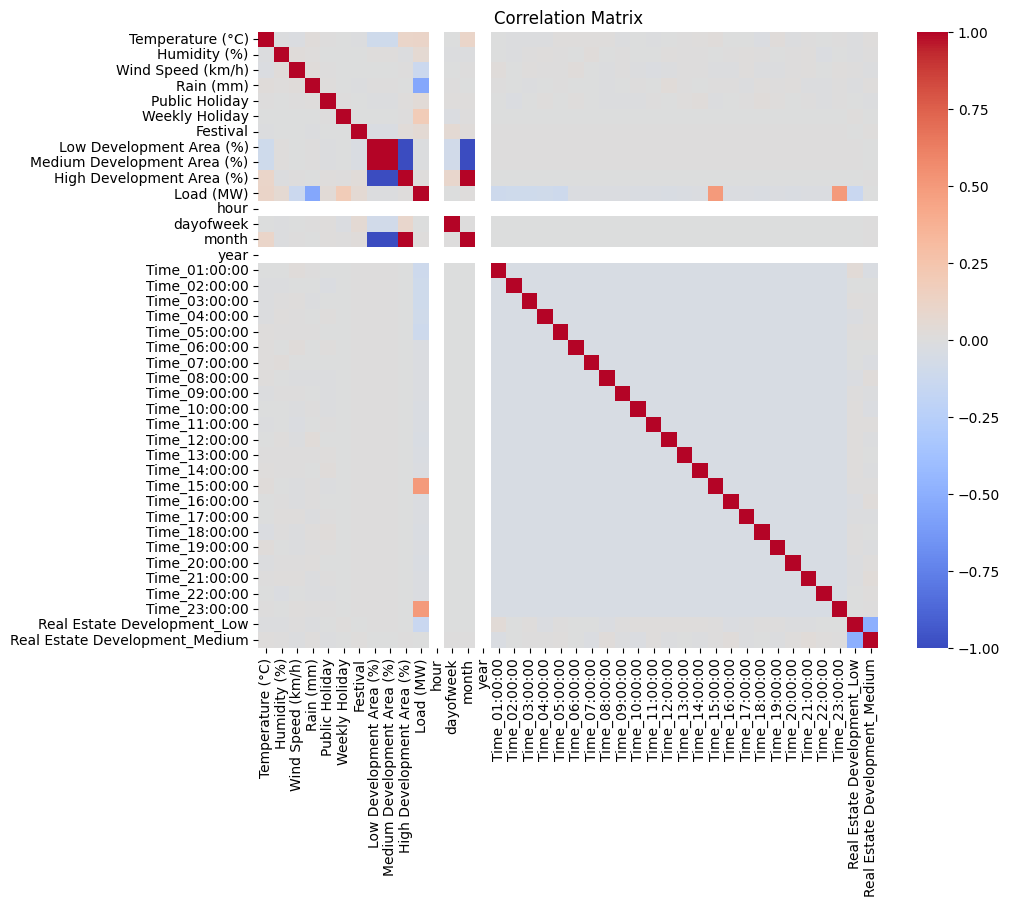

,Temperature (°C),Humidity (%),Wind Speed (km/h),Rain (mm),Public Holiday,Weekly Holiday,Festival,Low Development Area (%),Medium Development Area (%),High Development Area (%),...,Time_16:00:00,Time_17:00:00,Time_18:00:00,Time_19:00:00,Time_20:00:00,Time_21:00:00,Time_22:00:00,Time_23:00:00,Real Estate Development_Low,Real Estate Development_Medium
Temperature (°C),1.000000,-0.009130,-0.017271,0.019340,0.002770,-0.004126,-0.011164,-0.103510,-0.103510,0.103510,...,-0.002252,-0.007651,-0.015655,0.018614,-0.007962,0.006410,-0.000514,0.005031,-0.012606,0.010196
Humidity (%),-0.009130,1.000000,0.018013,0.013999,-0.004557,-0.000975,-0.004890,0.009122,0.009122,-0.009122,...,0.005502,0.009076,0.000657,-0.002183,0.004396,0.009653,-0.016088,-0.001398,-0.011387,0.004062
Wind Speed (km/h),-0.017271,0.018013,1.000000,0.017305,0.007132,-0.004345,-0.006581,-0.002368,-0.002368,0.002368,...,-0.008048,0.012713,-0.015395,-0.013367,0.003770,0.014688,-0.002409,0.013737,0.002832,-0.011205
Rain (mm),0.019340,0.013999,0.017305,1.000000,0.015592,-0.002727,-0.008537,0.003275,0.003275,-0.003275,...,0.005435,-0.008191,0.008561,0.002308,0.010284,-0.008413,-0.009576,0.003163,-0.012925,0.009564
Public Holiday,0.002770,-0.004557,0.007132,0.015592,1.000000,0.001113,-0.001718,-0.015470,-0.015470,0.015470,...,-0.001352,0.002264,0.016729,0.013113,-0.004969,0.005880,-0.012201,0.005880,-0.002109,-0.008409
Weekly Holiday,-0.004126,-0.000975,-0.004345,-0.002727,0.001113,1.000000,-0.000025,-0.000314,-0.000314,0.000314,...,-0.000038,-0.000038,-0.000038,-0.000038,-0.000038,-0.000038,-0.000038,-0.000038,0.010341,-0.006203
Festival,-0.011164,-0.004890,-0.006581,-0.008537,-0.001718,-0.000025,1.000000,-0.024050,-0.024050,0.024050,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,-0.001816,0.009548
Low Development Area (%),-0.103510,0.009122,-0.002368,0.003275,-0.015470,-0.000314,-0.024050,1.000000,1.000000,-1.000000,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.006753,-0.000976
Medium Development Area (%),-0.103510,0.009122,-0.002368,0.003275,-0.015470,-0.000314,-0.024050,1.000000,1.000000,-1.000000,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.006753,-0.000976
High Development Area (%),0.103510,-0.009122,0.002368,-0.003275,0.015470,0.000314,0.024050,-1.000000,-1.000000,1.000000,...,-0.000041,-0.000041,-0.000041,-0.000041,-0.000041,-0.000041,-0.000041,-0.000041,-0.006753,0.000976


Features used: ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Rain (mm)', 'Public Holiday', 'Weekly Holiday', 'Festival', 'Low Development Area (%)', 'Medium Development Area (%)', 'High Development Area (%)', 'dayofweek', 'month', 'Time_01:00:00', 'Time_02:00:00', 'Time_03:00:00', 'Time_04:00:00', 'Time_05:00:00', 'Time_06:00:00', 'Time_07:00:00', 'Time_08:00:00', 'Time_09:00:00', 'Time_10:00:00', 'Time_11:00:00', 'Time_12:00:00', 'Time_13:00:00', 'Time_14:00:00', 'Time_15:00:00', 'Time_16:00:00', 'Time_17:00:00', 'Time_18:00:00', 'Time_19:00:00', 'Time_20:00:00', 'Time_21:00:00', 'Time_22:00:00', 'Time_23:00:00', 'Real Estate Development_Low', 'Real Estate Development_Medium']

The file we are working at is  File Data set 4
--- Linear Regression ---
mean_absolute_error:  306.0816
mean_squared_error: 148103.7399
r2_score:    0.9493
--- KNN Regressor ---
mean_absolute_error:  481.4361
mean_squared_error: 398307.9265
r2_score:    0.8638
--- Random Forest Regressor ---
mean_a

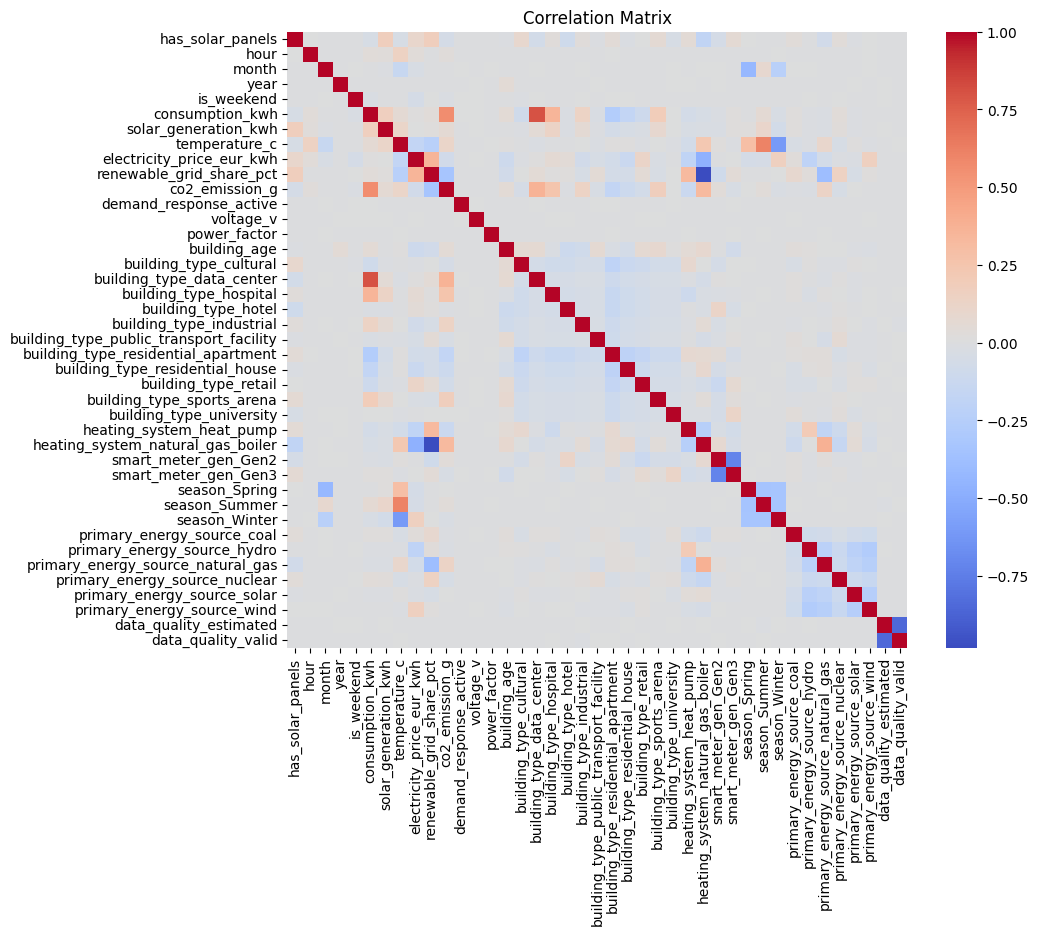

,has_solar_panels,hour,month,year,is_weekend,consumption_kwh,solar_generation_kwh,temperature_c,electricity_price_eur_kwh,renewable_grid_share_pct,...,season_Summer,season_Winter,primary_energy_source_coal,primary_energy_source_hydro,primary_energy_source_natural_gas,primary_energy_source_nuclear,primary_energy_source_solar,primary_energy_source_wind,data_quality_estimated,data_quality_valid
has_solar_panels,1.000000,0.001961,1.245104e-04,-0.001156,-0.001634,-0.042544,0.179347,-0.042353,0.098193,0.175297,...,-0.002799,-0.000512,0.034849,-0.002767,-0.078070,0.037120,-0.012118,0.007937,0.000348,7.480404e-04
hour,0.001961,1.000000,1.662356e-03,-0.000836,-0.000225,0.036035,0.026603,0.144934,0.037203,0.000007,...,-0.002258,0.002722,-0.003448,0.000966,0.001474,-0.001889,-0.002967,0.004274,-0.001147,-2.488200e-04
month,0.000125,0.001662,1.000000e+00,-0.004468,0.004221,-0.001605,-0.011374,-0.142844,-0.034656,-0.005145,...,0.082528,-0.234501,0.001967,0.002579,-0.001668,-0.004976,-0.001149,0.006224,-0.002412,9.236370e-07
year,-0.001156,-0.000836,-4.468300e-03,1.000000,-0.000477,-0.000905,-0.005012,0.000629,-0.000981,-0.001299,...,-0.001061,0.001506,-0.001386,-0.003754,-0.001142,0.001092,0.002557,0.000160,0.003105,-3.265321e-03
is_weekend,-0.001634,-0.000225,4.221489e-03,-0.000477,1.000000,-0.023885,-0.004432,-0.002346,-0.057783,0.002278,...,0.001254,-0.001706,-0.000228,0.003487,-0.000064,0.003608,-0.004595,-0.001876,0.002716,-1.161125e-03
consumption_kwh,-0.042544,0.036035,-1.604869e-03,-0.000905,-0.023885,1.000000,0.171746,0.057444,0.012678,0.037420,...,0.063116,-0.030056,0.022740,-0.011077,-0.018611,0.035051,-0.009937,-0.003217,-0.001048,-1.469084e-03
solar_generation_kwh,0.179347,0.026603,-1.137432e-02,-0.005012,-0.004432,0.171746,1.000000,0.112363,0.004877,0.022894,...,0.108734,-0.068667,0.025002,-0.008887,-0.018388,0.031574,-0.009990,-0.002451,0.002889,-3.778238e-03
temperature_c,-0.042353,0.144934,-1.428435e-01,0.000629,-0.002346,0.057444,0.112363,1.000000,-0.169438,-0.232074,...,0.610440,-0.607382,-0.029335,-0.009347,0.095116,-0.038113,0.015504,-0.006705,-0.002635,3.945996e-03
electricity_price_eur_kwh,0.098193,0.037203,-3.465565e-02,-0.000981,-0.057783,0.012678,0.004877,-0.169438,1.000000,0.354434,...,-0.051520,0.158248,0.025123,-0.192804,-0.069713,-0.006015,-0.016156,0.156860,-0.003022,1.383419e-03
renewable_grid_share_pct,0.175297,0.000007,-5.144646e-03,-0.001299,0.002278,0.037420,0.022894,-0.232074,0.354434,1.000000,...,-0.000939,0.006021,0.082035,0.030086,-0.385787,0.146572,-0.039142,0.024452,-0.004043,1.629352e-03


Features used: ['solar_generation_kwh', 'co2_emission_g', 'building_type_data_center', 'building_type_hospital', 'building_type_industrial', 'building_type_residential_apartment', 'building_type_residential_house', 'building_type_retail', 'building_type_sports_arena']

The file we are working at is  File Data set 5  'Best' 
--- Linear Regression ---
mean_absolute_error:  25.1966
mean_squared_error: 2733.3765
r2_score:    0.9173
--- KNN Regressor ---
mean_absolute_error:  12.7728
mean_squared_error: 1294.8525
r2_score:    0.9608
--- Random Forest Regressor ---
mean_absolute_error:  11.4645
mean_squared_error: 1402.4674
r2_score:    0.9576
######################################################################################################################
----------------------------------------------------------------------------------------------------------------------
----------------------------------- Based on this data we did Choose data set 5 which is data Set names 'Energy Cons

In [ ]:
file_1 = "Choosed\\electricity_consumption_optimization_dataset BULDING.csv" ## data set 3
file_2 = "Choosed\\delhi_power_load_dataset1 CITY.csv" ## data set 4
file_3 = "Choosed\\5.energy_consumption_grid.csv" ## data set 5


File = {"File Data set 3 ": file_1,"File Data set 4":file_2,"File Data set 5  'Best' ":file_3}


### we found that alot of files are not good so
###### made a loop to choose all files
ask = input("Do you want the visuals on? y/n") ### it has some visuals, asking if want to show it or not , visuales for the files and dataframe
    
for filename, i in File.items():
    elec = pd.read_csv(i) ### loop for read each file from the 3 data set
    elec.drop_duplicates(inplace=True)
    if i == file_1: #### Some logic and things that only could happens for file one
        # Remove duplicates
        elec = elec.drop_duplicates(subset=['Timestamp', 'Building Type'])
        if ask == "y":
            elec.info()
        ##
        elec.isna().sum() ## there is no missing values
        if ask == "y":
            elec.head()
        # Step 1: Convert Timestamp to datetime and extract useful features beacue getdummies can't preocces it easily
        elec['Timestamp'] = pd.to_datetime(elec['Timestamp'])
        elec['hour']      = elec['Timestamp'].dt.hour
        elec['day'] = elec['Timestamp'].dt.day
        elec['month']     = elec['Timestamp'].dt.month
        elec['year']     = elec['Timestamp'].dt.year
        if ask == "y":
            elec.head()
        elec.drop(columns=["Timestamp"],inplace=True)

        ### #####  some logic fixes  ######
        elec = elec[elec["Building Size (m²)"]>0]
        elec = elec[elec["Energy Consumption (kWh)"]>0]
        elec = elec[elec['HVAC Consumption (kWh)'] > 0]
        elec = elec[elec['Lighting Consumption (kWh)'] > 0]
        elec = elec[elec["Humidity (%)"]>0]
        elec = elec[elec["Humidity (%)"]<100]
        elec = elec[elec["Occupancy Rate (%)"]>0]
        elec = elec[elec["Occupancy Rate (%)"]<100]
        elec = elec[elec["Power Factor"]>0]
        elec = elec[elec["Power Factor"]<1]
        elec = elec[elec['Building Age (years)'] > 0]
        elec = elec[elec["Energy Efficiency Rating"]<100]
        elec = elec[elec['Energy Savings Potential (%)'] < 100]
        elec = elec[elec['Temperature (°C)'] > -15] 
        elec = elec[elec['Temperature (°C)'] < 50]
        elec = elec[elec['Indoor Temperature (°C)'] > -10]
        elec = elec[elec['Indoor Temperature (°C)'] < 45]
        filter = elec['Lighting Consumption (kWh)'] + elec['HVAC Consumption (kWh)'] < elec['Energy Consumption (kWh)']
        elec = elec[filter]

        #### the idea is if the temperatute in door is higher than out door, change the indoor (the hight one) change it with the out door for better logic 


        #### Droping columns that are not compile with businesses question, like some has consumption of energey of other subject "of course will not predic the consumption by using the already consumption"
        elec.drop(columns=["Lighting Consumption (kWh)"	,"HVAC Consumption (kWh)","Energy Price ($/kWh)","Carbon Emission Rate (g CO2/kWh)","Reactive Power (kVARh)","Smart Plug Usage (kWh)","Room-Level Energy Consumption (kWh)","Zonal Heating/Cooling Data (kWh)"],inplace=True)
        if ask == "y":
            elec.info()
        # Take random 10% of the data
        # elec = elec.sample(frac=0.01, random_state=42)
        # ### use polynomial features
        # poly = PolynomialFeatures(degree=2)
        # pol2 = poly.fit_transform(elec)

        # # ✅ CORRECT: Auto-generate column names
        # feature_names = poly.get_feature_names_out(input_features=elec.columns.to_list())
        # elec = pd.DataFrame(pol2, columns=feature_names)
        # print(elec)
        # 4. Feature Selection based on Heatmap

    if i == file_2: ### now fixing the the secound the file data only need some feature enginering for the file
        elec["Date"] = pd.to_datetime(elec['Date'])
        elec['hour']      = elec['Date'].dt.hour
        elec['dayofweek'] = elec['Date'].dt.day
        elec['month']     = elec['Date'].dt.month
        elec['year']     = elec['Date'].dt.year
        if ask == "y":
            elec.head()
        elec.drop(columns=["Date"],inplace=True)

    if i == file_3: ## now fixing the third file
        elec = elec[elec["consumption_kwh"] > 0]
        elec = elec[elec["solar_generation_kwh"] >= 0]
        elec = elec[elec["electricity_price_eur_kwh"] > 0]
        elec = elec[elec['temperature_c'] > -30] 
        elec = elec[elec['temperature_c'] < 55]
        #Grid Health Constraints (Standard European Grid values) Voltage should be around 230V (+/- 15%)
        elec = elec[elec["voltage_v"] > 195]
        elec = elec[elec["voltage_v"] < 265]
        # Frequency should be around 50Hz
        elec = elec[elec["grid_frequency_hz"] > 49.5]
        elec = elec[elec["grid_frequency_hz"] < 50.5]
        # Power Factor must be between 0 and 1
        elec = elec[elec["power_factor"] >= 0]
        elec = elec[elec["power_factor"] <= 1]
        elec['building_age'] = elec['year'] - elec['construction_year'] # as older usually mean worse so i transfered it from constraction year to building age
        elec.drop(columns=['construction_year','meter_id','city','country','district','timestamp','date', 'day_of_week', 'latitude', 'longitude', 'ai_forecast_kwh', 'ai_anomaly_detected', 'ai_efficiency_score', 'grid_frequency_hz', 'net_grid_draw_kwh'],inplace=True)
        if ask == "y":
            elec.info()
    elec["city"].unique()
    ## Now do this for all the files 
    ## Label encder for any catgorical feature for less unique value
    le = LabelEncoder()
    ftyui = elec.columns.tolist()
    for col in elec.columns:
        if elec[col].dtype == 'object':
            if len(elec[col].unique()) <= 2:
                elec[col] = le.fit_transform(elec[col])
    ### for rest do the one hot encoding ()
    elec = pd.get_dummies(elec,drop_first=True)


    plt.figure(figsize=(10, 8)) 
    corr_matrix = elec.corr() ### make correlation
    if ask == "y":
        print(corr_matrix) ### print the correlation matrix 
    sns.heatmap(corr_matrix, cmap='coolwarm') ### make the heat map 
    plt.title("Correlation Matrix")
    plt.show()
    display(corr_matrix)  #  display the correlation matrix again
    
    if i == file_3: ### some espcific data for each data set as the 
        k ='consumption_kwh' ### name of the target variables
        con = 0.1 ### correlation matrix when  to drop ,use in the next to drop the correlation with this rate
    if i == file_1:## for file 1
        k = "Energy Consumption (kWh)" ### name of the target variables
        con = 0.0005   ### correlation matrix when  to drop ,use in the next to drop the correlation with this rate
    if i == file_2: #for file 2
        k = "Load (MW)" ### name of the target variables
        con = 0.0005    ### correlation matrix when  to drop ,use in the next to drop the correlation with this rate
        
    corrs = corr_matrix[k].abs() ## absolute 
    selected_features = corrs[corrs > con].index.tolist()  ### drop any column that has correlation less than this variablies
    selected_features.remove(k) ### remove the target variables
    x = elec[selected_features] ## make the x data set
    y = elec[k]  ## make the target variable
    if ask == "y":
        print(x)

    # 5. Split and Standardize
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42) 
    
    ##### make the standard scaler for numerical data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) # 
    X_test_scaled = scaler.transform(X_test) ## only transform the data

    # 6. Train and Evaluate #### Need to use hyperprameters and loops to choose the best variables for each model for better accuarcy
    models = {
        "Linear Regression": LinearRegression(),  ## use this 3 models
        "KNN Regressor": KNeighborsRegressor(), 
        "Random Forest Regressor" :RandomForestRegressor(random_state=42,     # for reproducibility
        n_jobs=-1 )          
}

    print(f"Features used: {selected_features}\n") 
    print(f"The file we are working at is  {filename}")
    for name, model in models.items(): ### ## loops for each data set for each dataa set the 3 models
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        print(f"--- {name} ---")  ### get for each model the 3 kinds of error
        print(f"mean_absolute_error:  {mean_absolute_error(y_test, preds):.4f}")
        print(f"mean_squared_error: {mean_squared_error(y_test, preds):.4f}")
        print(f"r2_score:    {r2_score(y_test, preds):.4f}")    
    print("######################################################################################################################")
    print("----------------------------------------------------------------------------------------------------------------------")
print("----------------------------------- Based on this data we did Choose data set 5 which is data Set names 'Energy Consumption' -------------------------------------------------------------")





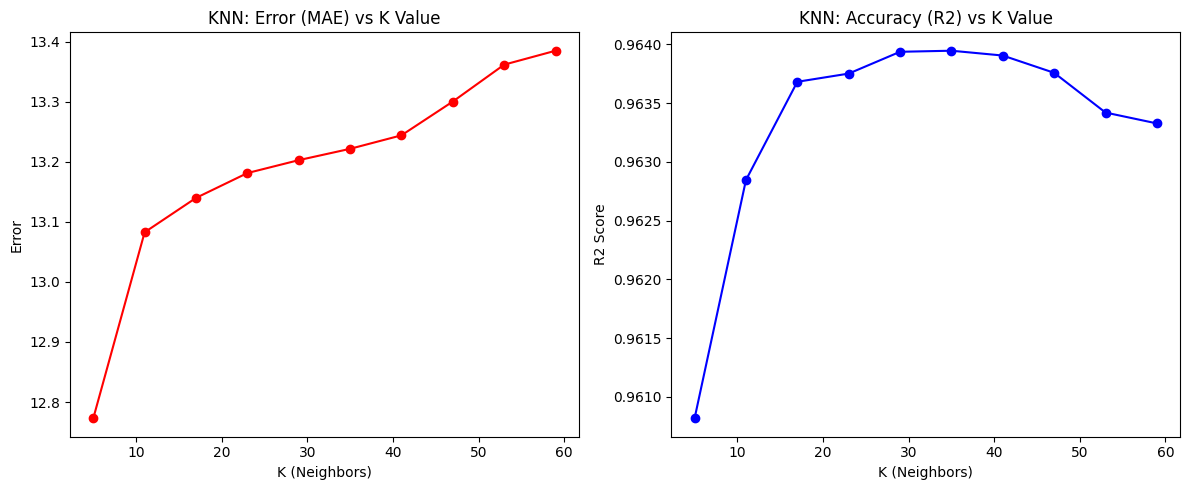

Best MAE: 12.7728 (K=5) | Best R²: 0.9639 (K=35)


In [ ]:

#Hyperpramter tuning
k_values = range(5,60,6) ### loop for all of this K values to see the best k by loops
knn_mae = [] # list of MAE values
knn_r2 = [] # List of R2 values

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k) ## k is loop for the knn 
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    knn_mae.append(mean_absolute_error(y_test, preds))
    knn_r2.append(r2_score(y_test, preds))

# Plotting the Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, knn_mae, marker='o', color='red', label='MAE') ### k values , mae score ,
plt.title('KNN: Error (MAE) vs K Value')
plt.xlabel('K (Neighbors)')
plt.ylabel('Error')
plt.tight_layout()

plt.subplot(1, 2, 2) ## one row, two column , secound Plot
plt.plot(k_values, knn_r2, marker='o', color='blue', label='R2') ### k values, R2 values
plt.title('KNN: Accuracy (R2) vs K Value')
plt.xlabel('K (Neighbors)')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

# Best MAE K
best_mae_k, best_mae_value = k_values[knn_mae.index(min(knn_mae))], min(knn_mae)

# Best R² K
best_r2_k, best_r2_value = k_values[knn_r2.index(max(knn_r2))], max(knn_r2)

print(f"Best MAE: {best_mae_value:.4f} (K={best_mae_k}) | Best R²: {best_r2_value:.4f} (K={best_r2_k})")


# HyperPramter Tuning with GridSearch and RandmizedSearch  

# New Q5 — How does hyperparameter tuning improve model performance, and what are the optimal settings for the best models?

#### Search for best paramter for the KNN regression

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint


param_grid = {
    'n_neighbors': [35],
    'metric': ['euclidean', 'manhattan', 'cosine']
    }#### gridsearchcv  

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=3, scoring='r2', n_jobs=-1) #### CV mean he use K fold cross validation
grid_search.fit(X_train_scaled, y_train)

print('Grid Search Best Parameters: ' + str(grid_search.best_params_))
print('Grid Search Best R2 Score: ' + str(round(grid_search.best_score_ , 4)))


###################################################################################################
best_knn_model = grid_search.best_estimator_  ### this is the best KNN Model 
###################################################################################################



c:\Users\khale\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.96270607 0.96337991        nan]
  warnings.warn(


Grid Search Best Parameters: {'metric': 'manhattan', 'n_neighbors': 35}
Grid Search Best R2 Score: 0.9634


### Choose the best Tree Count

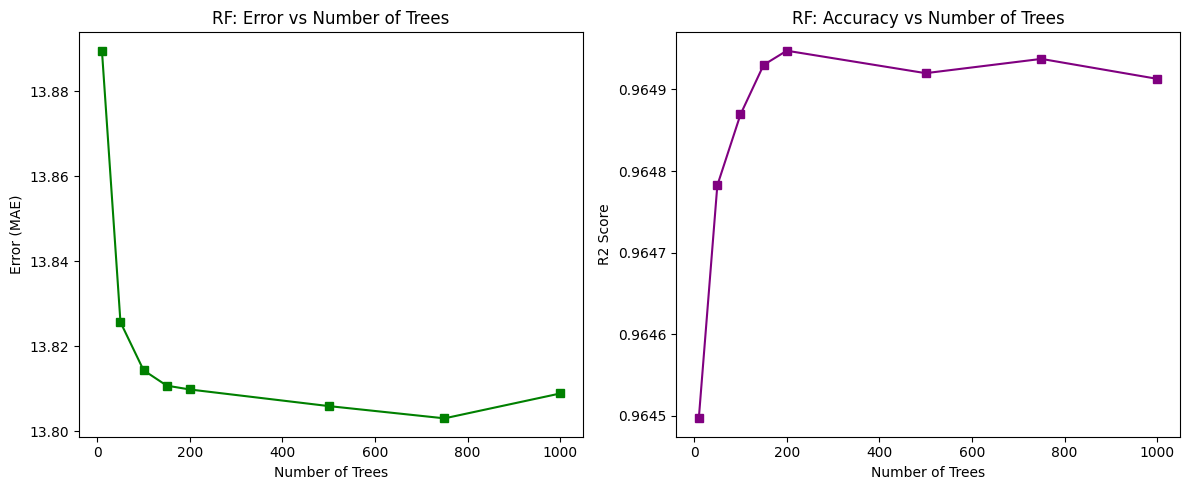

In [ ]:

tree_counts = [10, 50, 100, 150, 200, 250, 500, 750, 1000]
RandomForest_mae = []
RandomForest_r2 = []


for n in tree_counts:
    RandomForest = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42) 
    RandomForest.fit(X_train_scaled, y_train)
    preds = RandomForest.predict(X_test_scaled)
    RandomForest_mae.append(mean_absolute_error(y_test, preds))
    RandomForest_r2.append(r2_score(y_test, preds))


# Plotting the Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tree_counts, RandomForest_mae, marker='s', color='green')
plt.title('RF: Error vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Error (MAE)')
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(tree_counts, RandomForest_r2, marker='s', color='purple')
plt.title('RF: Accuracy vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()


# Best R²
best_r2_n = tree_counts[RandomForest_r2.index(max(RandomForest_r2))]

# Best MAE  
best_mae_n = tree_counts[RandomForest_mae.index(min(RandomForest_mae))]

print(f"Best R²: {max(RandomForest_r2):.4f} at n={best_r2_n}")
print(f"Best MAE: {min(RandomForest_mae):.4f} at n={best_mae_n}")


In [ ]:
#rf = RandomForestRegressor(
#    n_estimators=150,           # Number of trees (Each one take a sample and divide the data by there own question until get into conclution ) do this sample 150 time (not 150 question) each one has there own multiple questions, averaging all this questions
 #   max_depth=20,               # Tree depth limit ### maximum number of questions per each 1 tree
  #  min_samples_split=5,        # Split threshold ### minum accepted sample to take to make new question, if sample equal to 5 then stop asking questions this is enghou
   # min_samples_leaf=2,         # Leaf minimum size ## minumam accepted leaf (last sample size) if less than two (too specific) remove this last one in leaf 
    #max_features='sqrt',        # Features per split ### when dividing in each tree he make a question (how to choose this question) he choose this quesiton based on 
    #bootstrap=True,             # Resample data
    #random_state=42             # Seed )


### select the rest best parameters for random forest Refressor 
Select best : max_depth, min_samples_split, min_samples_leaf

In [ ]:

param_grid = {
    'n_estimators': [200],
    'max_depth': [10, 20, 30,None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [ 2, 4, 6]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf, param_grid, 
    n_iter=20,           
    cv=3,                
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2   )

search.fit(X_train_scaled, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best R²: {search.best_score_:.4f}")

######################################################################################################
best_random_forest_model = search.best_estimator_   ####   this is the best Random Forest Model   ####
######################################################################################################

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Best R²: 0.9650


### -------------------------------------------------------------------------------

### By the end I can say that hyperpramter Tuning did improve random forest model from (R2=0.9576) TO (R2=0.965) which is good increase
### and did make KNN resgrission increase by from (R2=0.9608) TO (R2=0.9634) which is also good and this how good and important is hyperpramter tuning

### -------------------------------------------------------------------------------

# New Q1 — Which machine learning model best predicts energy consumption, and what does its performance tell us about the predictability of the data?

## get the best model by write all the models and select the best

In [ ]:
# trained models

linear_regression_model = LinearRegression().fit(X_train_scaled, y_train)

models = {
    "Linear Regression": linear_regression_model,
    "KNN Regressor": best_knn_model,
    "Random Forest": best_random_forest_model
}

# Store results
results = []

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    if name =="Random Forest":
        print("------ 🏆 ------")
        print(f"Best parameter :  {search.best_params_}")
    if name == "KNN Regressor":
        print(f"Best parameter : {grid_search.best_params_}")
    print(f"mean_absolute_error:  {mean_absolute_error(y_test, preds):.4f}")
    print(f"mean_squared_error: {mean_squared_error(y_test, preds):.4f}")
    print(f"r2_score:    {r2_score(y_test, preds):.4f}") 

###3 this is the best model selected



--- Linear Regression ---
mean_absolute_error:  25.1966
mean_squared_error: 2733.3765
r2_score:    0.9173
--- KNN Regressor ---
Best parameter : {'metric': 'manhattan', 'n_neighbors': 35}
mean_absolute_error:  13.1664
mean_squared_error: 1182.0219
r2_score:    0.9642
--- Random Forest ---
------ 🏆 ------
Best parameter :  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
mean_absolute_error:  13.8134
mean_squared_error: 1156.9251
r2_score:    0.9650


### This is A model tester to test the model based on out best model but by removing somefeatures and add somefeatures and see the best model

In [ ]:

#2 Which features are the most correlated to the prediction of future combustions?

corrs = elec.corr()['consumption_kwh'].abs().sort_values(ascending=False)
top_10 = corrs.drop('consumption_kwh').head(10).index.tolist()
print(f"This is the top 10 correlated feature in the file : {top_10}")
print("Most correlated feature IS ","-"*15)
print(f"This is the top correlated feature in the file : {corrs.drop('consumption_kwh').head(1).index.tolist()}")
print("-"*(15+27))
#3 What is the correlation between energy demand and temperature, and how it can affect the prediction? # remove it , add it and see the diffrence in R2 score


needed_features = top_10 + ['temperature_c', 'hour']
def test_importance(features, label):
    X = elec[features]
    y = elec['consumption_kwh']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(n_estimators=200, max_depth=10,min_samples_split= 5, min_samples_leaf= 4, random_state=42)   ## with the best variables 
    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    print(f"{label} -> R2 Score: {r2:.4f}")
print("Running Importance Tests...\n")
test_importance(needed_features, "base_line")
test_importance([f for f in needed_features if f != 'co2_emission_g'], "Removing co2_emission_g")
test_importance([f for f in needed_features if f != 'solar_generation_kwh'], "Removing solar_generation_kwh")
test_importance([f for f in needed_features if f != 'temperature_c'], "Removing temperature_c")
test_importance([f for f in needed_features if f != 'building_age'], "Removing building_age")
test_importance([f for f in needed_features if f != 'hour'], "Removing hour")




This is the top 10 correlated feature in the file : ['building_type_data_center', 'co2_emission_g', 'building_type_hospital', 'building_type_residential_apartment', 'building_type_sports_arena', 'building_type_residential_house', 'solar_generation_kwh', 'building_type_industrial', 'building_type_retail', 'building_type_cultural']
Most correlated feature ---------------
This is the top correlated feature in the file : Index(['building_type_data_center'], dtype='object')
--------------------------------------
Running Importance Tests...

base_line -> R2 Score: 0.9827
Removing co2_emission_g -> R2 Score: 0.9607
Removing solar_generation_kwh -> R2 Score: 0.9823
Removing temperature_c -> R2 Score: 0.9691
Removing building_age -> R2 Score: 0.9827
Removing hour -> R2 Score: 0.9810


In [ ]:

### this is new added question
### NEW Q4 Question 2 ,Does standard (scaling) features significantly impact model performance across the three algorithms? You train each model with and without StandardScaler and compare. Linear Regression and KNN are heavily affected, Random Forest is not — this produces an interesting comparison


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

#### there is no standard scaling ######3
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor( metric='manhattan', n_neighbors=35), ### best parameters 
    "Random Forest Regressor" :RandomForestRegressor(n_estimators=200, max_depth=10,min_samples_split= 5, min_samples_leaf= 4, random_state=42)}


print(f"Features used: {selected_features}\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"--- {name} ---")
    print(f"mean_absolute_error:  {mean_absolute_error(y_test, preds):.4f}")
    print(f"mean_squared_error: {mean_squared_error(y_test, preds):.4f}")
    print(f"r2_score:    {r2_score(y_test, preds):.4f}")




Features used: ['solar_generation_kwh', 'co2_emission_g', 'building_type_data_center', 'building_type_hospital', 'building_type_industrial', 'building_type_residential_apartment', 'building_type_residential_house', 'building_type_retail', 'building_type_sports_arena']

--- Linear Regression ---
mean_absolute_error:  25.1966
mean_squared_error: 2733.3765
r2_score:    0.9173
--- KNN Regressor ---
mean_absolute_error:  59.2169
mean_squared_error: 16773.6124
r2_score:    0.4924
--- Random Forest Regressor ---
mean_absolute_error:  13.8133
mean_squared_error: 1156.9092
r2_score:    0.9650


### Knn really get affected by numbers scalling while others models no diffrince at all

# New Q5: Does the model generalize well, or does it overfit the training data?


How can we test the generaliztion, by predict the already the trained file, that already we did train it, if it get much higher than the x_test, (x_test he never saw it), (x_train, is the file that we already trained on) if the x_train is much higher than x_test this this mean it did save the data and have over fit

but if the x_train predicted and x_test predicted is close near each other mean, even in the data he see and data he didn't see, is not big diffrence in R2 this mean he genralize well and didn't over fit 

In [ ]:

models_gf = {
    "KNN Regrission": best_knn_model,
    "Random Forest": best_random_forest_model
}

results_overfit = []

for name, model in models_gf.items():
    # Training predictions
    train_pred = model.predict(X_train_scaled) ### predicit the trained
    test_pred = model.predict(X_test_scaled) ### predicit the test data as common
    
    train_r2 = r2_score(y_train, train_pred) ###  get the R2 of the x Train 
    test_r2 = r2_score(y_test, test_pred) ###  get the R2 of the x test
    diff = train_r2 - test_r2 ## see the diffrence
    
    # Diagnosis
    if diff < 0.02: # low diffrence is good
        R2_diff = "Excellent - Generalizes well"
    elif diff < 0.05:
        R2_diff = "GOOD - Slight overfitting"
    elif diff < 0.10:
        R2_diff = "Moderate - Some overfitting"
    else:
        R2_diff = " Poor generalization"
    #### print the diffrences and results
    results_overfit.append({'model': name,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'diffrince': diff,
        'R2_diff': R2_diff})
    
    print(f"\n--- {name} ---")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²:  {test_r2:.4f}")
    print(f"  Difference: {diff:.4f}")
    print(f"  R2_diff: {R2_diff}")
    






--- KNN Regrission ---
  Train R²: 0.9657
  Test R²:  0.9642
  Difference: 0.0015
  R2_diff: Excellent - Generalizes well

--- Random Forest ---
  Train R²: 0.9680
  Test R²:  0.9650
  Difference: 0.0030
  R2_diff: Excellent - Generalizes well


# Now LETS ENTER TO THE MOST IMPORTANT THING?

# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



# THE BIG ONE

# LETS MAKE A MODEL THAT WE GIVE HIM OUR DATA AND THEN HE PREDICT WHAT ARE THE CONSUMTIONS OF THIS DATA WE GAVE

In [ ]:
print(X_train)
display(X_train_scaled)
##########################################################################################################################################
########################################## IMPORTANT DON'T MISSS ##############################################
### asks
####    This model ask you questions , some question about some features 
solar = input("enter a 'solar_generation_kwh' : (as 0) ")
co2_emission_g = input("enter a 'co2_emission_g' : (as 47.5) ")
building_type_data_center = input("enter 'building_type_data_center' : (As False is 0 True is 1)")
building_type_hospital = input("enter 'building_type_hospital' : (As False True)")
building_type_industrial = input("enter 'building_type_industrial' : (As False True)")
building_type_residential_apartment = input("enter 'building_type_residential_apartment' : (As False True)")
building_type_residential_house = input("enter 'building_type_residential_house' : (As False True)")
building_type_retail = input("enter 'building_type_retail' : (As 0 1)")
building_type_sports_arena = input("enter 'building_type_sports_arena' : (As False True)")
### after anwsering the questions

all_columns = [  ###  all colummns of the file
    'solar_generation_kwh', 'co2_emission_g', 'building_type_data_center',
    'building_type_hospital', 'building_type_industrial', 
    'building_type_residential_apartment', 'building_type_residential_house',
    'building_type_retail', 'building_type_sports_arena'
]


# Initialize dataframe for future use it as the x_test , 
user_data = pd.DataFrame(0, index=[0], columns=all_columns)

### add to this dateframe each data we asked about
user_data['solar_generation_kwh'] = solar
user_data['co2_emission_g'] = co2_emission_g
user_data['building_type_data_center'] = building_type_data_center
user_data['building_type_hospital'] = building_type_hospital
user_data['building_type_industrial'] = building_type_industrial
user_data['building_type_residential_apartment'] = building_type_residential_apartment
user_data['building_type_residential_house'] = building_type_residential_house
user_data['building_type_retail'] = building_type_retail
user_data['building_type_sports_arena'] = building_type_sports_arena


# Scale features
user_data_scaled = scaler.transform(user_data) ### scale this data based in before scalling
# Get the predicted kWh
predicted_kwh = model.predict(user_data_scaled)[0] ### predict this data to get the predications
print(predicted_kwh) ### print the predictions ####### most important part



        solar_generation_kwh  co2_emission_g  building_type_data_center  \
104025                   0.0            47.5                      False   
5415                     0.0           680.7                      False   
75612                    0.0           153.0                      False   
138169                   0.0           960.8                      False   
87184                    0.0           240.3                      False   
...                      ...             ...                        ...   
119879                   0.0          5578.3                      False   
103694                   0.0            28.4                      False   
131932                   0.0         20233.7                      False   
146867                   0.0        139308.3                      False   
121958                   0.0          1644.3                      False   

        building_type_hospital  building_type_industrial  \
104025                   False         

array([[-0.12025436, -0.31696017, -0.18717897, ...,  2.71961498,
        -0.29724805, -0.19960794],
       [-0.12025436, -0.30173477, -0.18717897, ..., -0.36769911,
        -0.29724805, -0.19960794],
       [-0.12025436, -0.31442341, -0.18717897, ..., -0.36769911,
        -0.29724805, -0.19960794],
       ...,
       [-0.12025436,  0.16842029, -0.18717897, ..., -0.36769911,
        -0.29724805, -0.19960794],
       [-0.12025436,  3.03158841, -0.18717897, ..., -0.36769911,
        -0.29724805,  5.00982072],
       [-0.12025436, -0.27856486, -0.18717897, ..., -0.36769911,
        -0.29724805, -0.19960794]], shape=(120000, 9))

62.326566587301556
